**Diplomado IA: Inteligencia Artificial II - Parte 2**. <br> Practico Aprendizaje Autosupervisado
---
---

**Profesores:**
- Sebastian Amenabar

**Instrucciones**
- Por favor priorizar realizar las dudas en el foro del curso porque pueden ser utiles para todos.
- Este practico debe ser desarrollado de forma individual, en caso de detectarse copia se pondra nota 1.0.
- Personas que entreguen de forma grupal aplicara el mismo criterio que para el caso de copia y se pondra nota 1.0.
- A pesar de lo anterior, es aceptado e incluso incentivado colaborar, compartir ideas y trabajar de forma conjunta, lo que es requerido es que la elaboracion y redaccion de las respuestas sea estricamente individual.
- En caso de que se pida ejecutar celdas de codigo, debe incluir las ejecuciones y resultados de estas en su entrega.


# Introducción

En este laboratorio veremos como podemos implementar el trabajo [Unsupervised Data Augmentation for Consistency Training](https://arxiv.org/abs/1904.12848) (UDA) y utilizarlo para complementar el entrenamiento de un modelo para clasificar de texto con muy pocos datos etiquetados.
El contenido de este cuaderno esta fuertemente basado en la implementación [original](https://github.com/google-research/uda) (en Tensorflow) y una posterior [reimplementación](https://github.com/SanghunYun/UDA_pytorch) en Pytorch.

Cómo vimos en la clase, UDA puede ser considerado como aprendizaje semi-supervisado y aprovecha datos no etiquetados (fáciles de conseguir) para mejorar el rendimiento en escenarios en los cuales tenemos pocos datos etiquetados. De todas formas, si tuviesemos muchos datos etiquetados UDA puede mejorar el rendimiento.

El método se basa en que hay ciertas transformaciones que no cambian la etiqueta de un dato. Por ejemplo, si se cambia una palabra por su sinónimo, no cambia el hecho de que la palabra sea positiva o negativa. Se puede aprovechar esto para forzar esa consistencia que debe existir entre un dato y su versión transformada. Esto se puede ver reflejado en la imagen a continuación: En la rama izquierda se utiliza aprendizaje supervisado tradicional para minimizar la pérdida (por ejemplo, entropía cruzada) de un modelo _M_. En la rama derecha, se utiliza aprendizaje no supervisado aprovechando la consistencia que debe existir entre un dato no etiquetado $x_{unlabeled}$ y la versión aumentada de ese dato $\hat{x}_{unlabeled}$.

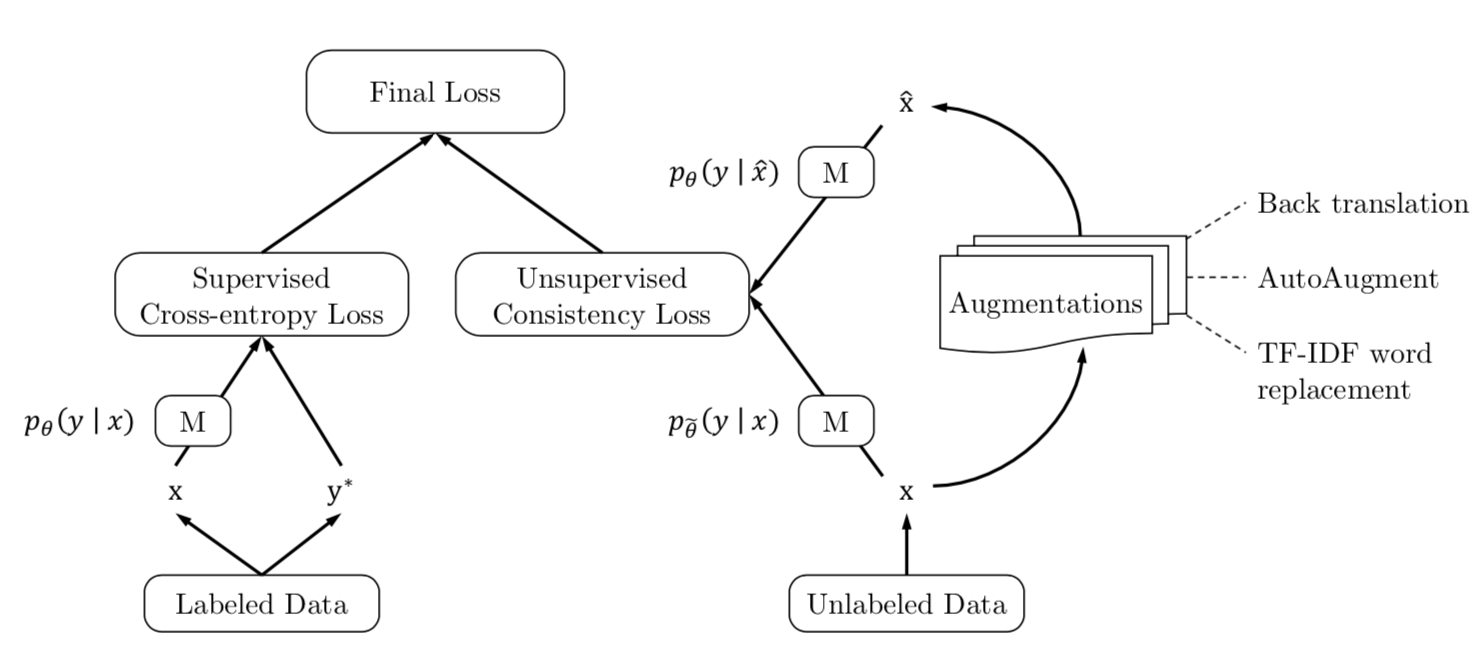

# Pérdida de consistencia

## Consistencia de qué?

En una tarea de clasificación típica, la salida del modelo es una distribución de probabilidad sobre una cantidad predefinida de clases. Por ejemplo, supongamos que le pasamos como entrada a un modelo una imagen sin etiquetar, una versión transformada de la imagen y para cada una genera como salida la distribución de probabilidad sobre 2 clases, como se ve en el gráfico a continuación.

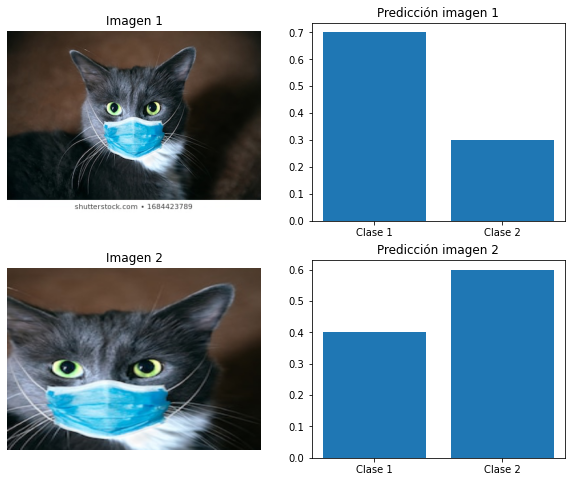

Podemos notar que ambas imágenes tienen un contenido similar, por lo que la predicción del modelo también debería serlo, pero no lo es. UDA penaliza estos casos para que el modelo genere predicciones similares  __(en específico, en el paper de UDA hacen que la predicción de la imagen 2, la aumentada, se mueva en dirección de la imagen 1 sin aumentar)__.

Matemáticamente está representado que:
$$
P(y|x_{unsupervised}) \neq P(y|\hat{x}_{unsupervised})
$$

Para hacer que estas dos predicciones sean iguales podemos utilizar la KL-Divergencia, una métrica que dice qué tan distintas son dos distribuciones (no es una distancia ya que no es simétrica), y toma valor cero cuando ambas son idénticas, por lo en la función de pérdida sumamos el término:
$$
KL(P(y|\hat{x}_{unsupervised})\ ||\ P(y|x_{unsupervised}))
$$


# Implementación para clasifación de sentimiento en reseñas de películas

## Descargas

Descargamos los datos que vamos a usar, incluyendo checkpoints de modelos

In [ ]:
!gdown 1P4zbCqS9he5PvXvPBcC_-60l-LiY8nNC
!gdown 1z8IonPgm4oBx1idYK_hxTwyThqzFV9Tc
!gdown 1ACDlIUbVoXpUWK6l0p7-f7P7SEc1AWla
!gdown 1bDX2w4qd02q6c3_iYskEpQ1qQtNTiLDQ
!gdown 1pa4H09o08HJXPO3fs3xhkKbMeAgwKXuC -O uda_best3.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1P4zbCqS9he5PvXvPBcC_-60l-LiY8nNC
From (redirected): https://drive.google.com/uc?id=1P4zbCqS9he5PvXvPBcC_-60l-LiY8nNC&confirm=t&uuid=2c8f8cbc-3fec-4e51-994b-3ca66aedc98f
To: /content/imdb_back_trans.zip
100% 47.1M/47.1M [00:01<00:00, 29.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1z8IonPgm4oBx1idYK_hxTwyThqzFV9Tc
From (redirected): https://drive.google.com/uc?id=1z8IonPgm4oBx1idYK_hxTwyThqzFV9Tc&confirm=t&uuid=0f6e3042-643e-448a-881b-9136029fb362
To: /content/IMDB_raw.zip
100% 173M/173M [00:03<00:00, 48.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1ACDlIUbVoXpUWK6l0p7-f7P7SEc1AWla
From (redirected): https://drive.google.com/uc?id=1ACDlIUbVoXpUWK6l0p7-f7P7SEc1AWla&confirm=t&uuid=a35ad083-d1dd-457c-9ac4-1ab620f53313
To: /content/std_full_best2.tar.gz
100% 402M/402M [00:06<00:00, 60.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bDX2w4qd02q6c3_iYskEpQ1q

In [ ]:
%%time
# Dataset IMDB

!mkdir IMDB_raw && unzip IMDB_raw.zip && rm IMDB_raw.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: IMDB_raw/aclImdb/train/unsup/20314_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/37010_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/29322_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/35854_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/32436_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/37765_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/4396_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/20895_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/18776_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/22375_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/27706_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/8027_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/5505_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/39530_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/35814_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/36417_0.txt  
  inflating: IMDB_raw/aclImdb/train/unsup/2166

### Descarga backtranslations

In [ ]:
%%time
# Datos ya aumentados con back-translation
!unzip imdb_back_trans.zip && rm imdb_back_trans.zip

Archive:  imdb_back_trans.zip
   creating: imdb_back_trans/
   creating: imdb_back_trans/unsup_in/
   creating: imdb_back_trans/unsup_in/sample_0.9/
   creating: imdb_back_trans/unsup_in/sample_0.9/para/
  inflating: imdb_back_trans/unsup_in/sample_0.9/para/para_0.txt  
CPU times: user 5.63 ms, sys: 118 µs, total: 5.75 ms
Wall time: 1.21 s


### Transformers

Debido a actualizaciones de la versión que Colab utiliza hay problemas de compatibilidad, por lo que debemos instalar una versión anterior de Python

Después de instalar Python 3.9, al entrar en la configuración de `Entorno de Ejecución` y `Cambiar tipo de entorno de ejecución`, aparecerá el nuevo tipo de entory py39, que debemos seleccionar y después, **IMPORTANTE: SE DEBE REFRESCAR LA PESTANA**

Verificamos que estemos trabajando con la versión 3.9 de Python

Y procedemos a instalar las dependencias

In [ ]:
!pip install numpy==2.0.2 packaging==26.2 pandas==2.2.2
!pip install torch==2.11.0+cu128
!pip install transformers==5.9.0
!pip install tokenizers==0.22.2 sentence-transformers==5.5.1 sentencepiece==0.2.1 optree==0.19.1

### Modelos preentrenados

In [ ]:
# Modelos de este experimento preentrenados

!gzip -dc /content/std_full_best2.tar.gz | tar -xvzf -
!gzip -dc /content/std_low_best.tar.gz | tar -xvzf -
!gzip -dc /content/uda_best3.tar.gz | tar -xvzf -

std_full_best2.pth/
std_full_best2.pth/pytorch_model.bin
std_full_best2.pth/config.json
std_low_best.pth/
std_low_best.pth/pytorch_model.bin
std_low_best.pth/config.json
uda_best4.pth/
uda_best4.pth/pytorch_model.bin
uda_best4.pth/config.json


## Importar librerías a usar

Importamos las librerías que vamos a usar

In [ ]:
import os
import os.path as osp
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm

/tmp/ipykernel_25484/2340482041.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Datos

### Carga de datos

Tenemos nuestro archivo de datos ya preparado en formato csv

In [ ]:
DATA_ROOT = "IMDB_raw/csv/"
train_df = pd.read_csv(osp.join(DATA_ROOT, "train.csv"), sep="\t")
test_df = pd.read_csv(osp.join(DATA_ROOT, "test.csv"), sep="\t")

In [ ]:
train_df.head()

,content,label,id
0,"Even worse than the worst David Lynch ""confusa...",neg,neg_9851_1.txt
1,We laughed our heads off. This script is so in...,neg,neg_4681_4.txt
2,"Yes, I was lucky enough to see the long-runnin...",neg,neg_3386_2.txt
3,"Vodka Lemon is a charming, yet extremely uneve...",neg,neg_6068_4.txt
4,"I wanted to watch this movie, but one bizarre ...",neg,neg_11186_2.txt


Podemos ver que en nuestros datos hay 50.000 ejemplos sin etiqueta, 12.500 con calificación positiva y 12.500 con calificación negativa.

In [ ]:
train_df["label"].value_counts()

,count
label,
unsup,50000
neg,12500
pos,12500


Cómo en la implementación original, quitamos lo texos sin etiquetar con menos de 500 caracteres, lo que deja 44.972 textos sin etiqueta.

In [ ]:
train_df = train_df[(train_df['content'].str.len() >= 500) | (train_df['label'] != 'unsup')]
train_df["label"].value_counts()

,count
label,
unsup,44972
neg,12500
pos,12500


### Aumentación de datos

En este caso vamos a utilizar el truco de back-translation, consistente en traducir el texto hasta un idioma destino y después traducir de vuelta al idioma original, esto produce un texto que es distinto, pero debería conservar su significado. Veremos como hacer este proceso en las actividades

Este es un proceso que en realidad es bastante lento por lo que nosotros utilizamos los datos ya procesados. Tenemos los 69.972 textos:

In [ ]:
BACK_TRANSLATION_FP = "imdb_back_trans/unsup_in/sample_0.9/para/para_0.txt"
with open(BACK_TRANSLATION_FP, "r") as f:
    back_translations = f.readlines()

len(back_translations)

69972

Los agregamos a nuestro DataFrame

In [ ]:
train_df["bt"] = back_translations

Y tomemos 2 ejemplos para ver como anda el backtranslation.

Primero vamos a ver un ejemplo en que el back-translation funciona bastante mal, cambiando completamente el significado del texto.

In [ ]:
i = 0
print("ORIGINAL:\n")
print(train_df.iloc[i]["content"])

print("\nBacktranslation:\n")
print(train_df.iloc[i]["bt"])

ORIGINAL:

Even worse than the worst David Lynch "confusathon", "Brain Dead" makes no sense whatsoever. Shamefully wasted talent (Bill Pullman, Bill Paxton), bounce around like they are in a "Tom and Jerry" cartoon on acid. There is negligible character development. It simply starts climbing the "strange scale", until climaxing in total chaos. Do not get sucked into this because of the above fine actors. They are given nothing to work with, and you will be wondering what's going on throughout the entire, unbearable 85 minutes. I highly recommend avoiding "Brain Dead" at all costs, unless you are into scattering your brain into total nonsense. - MERK

Backtranslation:

flying black, multed man grond the life, of uawcomm is in cold season!Against the ritie of deviation required by the Bob, forget Halloween, put yourself Fantasy River, or◆Fighter Cryptosportep, Staff Sussex & woolves, is in black when you leave your own emotionplanned. Screened talent (Bill Pullman, Bill Paxton) is redund

Y ahora uno en que funciona bien, cambiando algunas palabras pero manteniendo el significado global del texto.

In [ ]:
i = 38000
print("ORIGINAL:\n")
print(train_df.iloc[i]["content"])

print("\nBacktranslation:\n")
print(train_df.iloc[i]["bt"])

ORIGINAL:

John Boorman's Excalibur is a brilliant re-telling of the grand legend of the Western European world, the once and future king, Arthur of Britain. It pares the Malory epic down to its basic core and recreates an entire fantastic world--the myth of Arthur, not the historical reality of Arthur. It suceeds magnificently. If you love fantasy you will love Excalibur. Furthermore, the music is divine: Siegfried's Funeral March (the sword's motif), more Wagner (Lohengrin and Parzival), plus the Carmina Burana. Highly recommended--all other Arthurian films fade to black and vanish in one's mind once you have seen Excalibur.

Backtranslation:

John Boorman's Excalibur is a brilliant adapté for Rumanian Western Europe to describe the great legend of the world, the king of the ancient and moving paragraphe Arthur of Britain. "You can't get anything at all," he said. Nadlyb fancy and no other great duo tour, the first of its kind on the TV stage and succeeds in the Musical Festival pub.

### Separación de datos

Vamos a tomar 10.000 ejemplos positivos y 10.000 negativos para entrenamiento tradicional, dejando 2.500 de cada uno para evaluación. Además, para ver como funciona UDA vamos a construir un dataset con solamente 10 ejemplos etiquetados de cada grupo y utilizando todos los restantes para la pérdida de consistencia.

In [ ]:
N_TRAIN = 10000
N_TRAIN_UDA = 10

all_train_data = train_df[train_df["label"] == "pos"].iloc[:N_TRAIN]
all_train_data = pd.concat((all_train_data, train_df[train_df["label"] == "neg"].iloc[:N_TRAIN]))

unsup_all_train_data = pd.concat((all_train_data, train_df[train_df["label"] == "unsup"]))

train_data20 = train_df[train_df["label"] == "pos"].iloc[:N_TRAIN_UDA]
train_data20 = pd.concat((train_data20, train_df[train_df["label"] == "neg"].iloc[:N_TRAIN_UDA]))

val_data = train_df[train_df["label"] == "pos"].iloc[N_TRAIN:]
val_data = pd.concat((val_data, train_df[train_df["label"] == "neg"].iloc[N_TRAIN:]))

print("All Train")
print(all_train_data["label"].value_counts())

print("Unsup All Train Data")
print(unsup_all_train_data["label"].value_counts())

print("Train-20")
print(train_data20["label"].value_counts())

print("Validation")
print(val_data["label"].value_counts())

All Train
label
pos    10000
neg    10000
Name: count, dtype: int64
Unsup All Train Data
label
unsup    44972
pos      10000
neg      10000
Name: count, dtype: int64
Train-20
label
pos    10
neg    10
Name: count, dtype: int64
Validation
label
pos    2500
neg    2500
Name: count, dtype: int64


In [ ]:
class Dataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, index):
        x = self.X[index]
        return x, self.y[index]

    def __len__(self):
        return len(self.X)

In [ ]:
all_train_dataset = Dataset(
    all_train_data["content"].values,
    (all_train_data["label"] == "pos").values.astype(np.longlong), # A los ejemplos positivos les asignamos etiqueta 1 y a los negativos 0
)

print(all_train_dataset[0])
print(all_train_dataset[9999])
print(all_train_dataset[10000])

('To like this movie at most you must be a)strongly in love (without a marriage) b) acknowledge English humor which is about admiring gallant and witty life situations and not just running gags c) be fairly very intelligent, because authors gave an opportunity to laugh and cry over every single minute of this movie, and only if you meet "b" and "c" requirements, you can recognize and enjoy author\'s input. d) to fully enjoy the movie you must love women like Kirsted Dunst, who is so natural, sweet and irresistible. e)you must admire creative, a little melancholic people with great and remarkable personalities  if you meet all these requirements you\'ll be likely to rate this movie near 10 points.  I never laughed half(!) as much as from watching this masterpiece. And i even managed to cry while laughing in some moments (i always get sensitive, whenever good things happen to Kirsten Dunst)', np.int64(1))
('Silly, hilarious, tragic, sad, inevitable.  A group of down-and-outs team up with

In [ ]:
unsup_all_train_dataset = Dataset(
    unsup_all_train_data["content"].values,
    unsup_all_train_data["bt"].values,
)

print(unsup_all_train_dataset[0])
print(unsup_all_train_dataset[9999])
print(unsup_all_train_dataset[10000])

('To like this movie at most you must be a)strongly in love (without a marriage) b) acknowledge English humor which is about admiring gallant and witty life situations and not just running gags c) be fairly very intelligent, because authors gave an opportunity to laugh and cry over every single minute of this movie, and only if you meet "b" and "c" requirements, you can recognize and enjoy author\'s input. d) to fully enjoy the movie you must love women like Kirsted Dunst, who is so natural, sweet and irresistible. e)you must admire creative, a little melancholic people with great and remarkable personalities  if you meet all these requirements you\'ll be likely to rate this movie near 10 points.  I never laughed half(!) as much as from watching this masterpiece. And i even managed to cry while laughing in some moments (i always get sensitive, whenever good things happen to Kirsten Dunst)', 'To love this film you must at most be a resolute (non-married) lover b) admitting the English h

In [ ]:
train20_dataset = Dataset(
    train_data20["content"].values,
    (train_data20["label"] == "pos").values.astype(np.longlong),
)

print(train20_dataset[0])
print(train20_dataset[9])
print(train20_dataset[10])

('To like this movie at most you must be a)strongly in love (without a marriage) b) acknowledge English humor which is about admiring gallant and witty life situations and not just running gags c) be fairly very intelligent, because authors gave an opportunity to laugh and cry over every single minute of this movie, and only if you meet "b" and "c" requirements, you can recognize and enjoy author\'s input. d) to fully enjoy the movie you must love women like Kirsted Dunst, who is so natural, sweet and irresistible. e)you must admire creative, a little melancholic people with great and remarkable personalities  if you meet all these requirements you\'ll be likely to rate this movie near 10 points.  I never laughed half(!) as much as from watching this masterpiece. And i even managed to cry while laughing in some moments (i always get sensitive, whenever good things happen to Kirsten Dunst)', np.int64(1))
("Given the low budget and production limitations, this movie is very good. It is p

In [ ]:
bt_dataset = Dataset(
    unsup_all_train_data["content"].values, unsup_all_train_data["bt"].values)
bt_dataset[0]

('To like this movie at most you must be a)strongly in love (without a marriage) b) acknowledge English humor which is about admiring gallant and witty life situations and not just running gags c) be fairly very intelligent, because authors gave an opportunity to laugh and cry over every single minute of this movie, and only if you meet "b" and "c" requirements, you can recognize and enjoy author\'s input. d) to fully enjoy the movie you must love women like Kirsted Dunst, who is so natural, sweet and irresistible. e)you must admire creative, a little melancholic people with great and remarkable personalities  if you meet all these requirements you\'ll be likely to rate this movie near 10 points.  I never laughed half(!) as much as from watching this masterpiece. And i even managed to cry while laughing in some moments (i always get sensitive, whenever good things happen to Kirsten Dunst)',
 'To love this film you must at most be a resolute (non-married) lover b) admitting the English 

In [ ]:
val_dataset = Dataset(
    val_data["content"].values,
    (val_data["label"] == "pos").values.astype(np.longlong),
)
val_dataset[0]

('The film begins with a bunch of kids in reform school and focuses on a kid named \'Gabe\', who has apparently worked hard to earn his parole. Gabe and his sister move to a new neighborhood to make a fresh start and soon Gabe meets up with the Dead End Kids. The Kids in this film are little punks, but they are much less antisocial than they\'d been in other previous films and down deep, they are well-meaning punks. However, in this neighborhood there are also some criminals who are perpetrating insurance fraud through arson and see Gabe as a convenient scapegoat--after all, he\'d been to reform school and no one would believe he was innocent once he was framed. So, when Gabe is about ready to be sent back to "The Big House", it\'s up to the rest of the gang to save him and expose the real crooks.  The "Dead End Kids" appeared in several Warner Brothers films in the late 1930s and the films were generally very good (particularly ANGELS WITH DIRTY FACES). However, after the boys\' contr

In [ ]:
test_dataset = Dataset(
    test_df["content"].values,
    (test_df["label"] == "pos").values.astype(np.longlong),
)
test_dataset[0]

("  Her Excellency Madam Shabana Azmi has worked in countless movies over life time. I think best is yet to come.  Fire is ok.  But still good days are yet to come.  Hopefully, in Water I will be able see her better.  Thanks and Regards.  PS: India doesn't have a director to make best use of her.",
 np.int64(1))

## Modelo
Utilizamos el modelo [BERT preentrenado](https://huggingface.co/transformers/model_doc/bert.html) de HuggingFace que es muy fácil de usar y provee un tokenizador

In [ ]:
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch
import torch.nn as nn

model_name = "bert-base-cased"
Tokenizer = BertTokenizerFast
# Los modelos para clasificación de secuencia de HuggingFace vienen con
# 2 capas lineales sobre el modelo para utilizar para la clasificación
Model = BertForSequenceClassification

In [ ]:
tokenizer = Tokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(list_of_strs):
    return tokenizer(
        list_of_strs,
        # Usamos largo máximo de 128 ya que es menos demandante computacionalmente,
        # pero con una mayor largo poría tener mejor rendimiento
        max_length=128,
        # Le decimos al tokenizar que retorne tensores de pytorch
        return_tensors="pt",
        # Rellene textos de distinto largo con padding
        padding=True,
        # Y si hay un texto más largo que el máximo permitido lo trunque
        truncation=True,
    )

# Las funciones de agregación reciben listas de textos/etiquetas
# y los textos procesados por el tokenizador
# o la concatenación de todas las etiquetas en un tensor
def collate_fn(list_of_data):
    tokens = tokenize([d[0] for d in list_of_data])
    labels = torch.as_tensor([d[1] for d in list_of_data])
    return (tokens, labels)

def collate_fn_unsup(list_of_data):
    tokens = tokenize([d[0] for d in list_of_data])
    back_translated = tokenize([d[1] for d in list_of_data])
    return (tokens, back_translated)

In [ ]:
# unsup_ratio dice que en cada batch vamos a incluir
# 3 ejemplos no supervisados por cada ejemplo supervisado
unsup_ratio = 3
# El tamaño de batch para los ejemplos supervisados
train_batch_size = 16
val_batch_size = 64

# Este es el loader con 20.000 datos
all_train_loader = torch.utils.data.DataLoader(
    all_train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
    drop_last=True
)
# Loader con 20 datos
train_loader20 = torch.utils.data.DataLoader(
    train20_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
    drop_last=False,
)
# Loader de todos los datos sin etiqueta
unsup_loader = torch.utils.data.DataLoader(
    bt_dataset,
    batch_size=train_batch_size * unsup_ratio,
    shuffle=True,
    collate_fn=collate_fn_unsup,
    pin_memory=True,
    drop_last=True,
)
# Loader de validación
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=train_batch_size * unsup_ratio,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    drop_last=False,
)
# Loader de testing
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=train_batch_size * unsup_ratio,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    drop_last=False,
)

## Optimizador

Vamos a utilizar BertAdam, que es un optimizador estándar utilizado comúnmente para BERT. No es necesario que entienda cómo funciona, está fuera del alcance de esta clase.

In [ ]:
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def make_optimizer_and_scheduler(model, lr, warmup, total_steps, weight_decay=0.01, eps=1e-6):
    # warmup can be a fraction like 0.1 or an integer number of steps
    if isinstance(warmup, float):
        warmup_steps = int(warmup * total_steps)
    else:
        warmup_steps = int(warmup)

    no_decay = ("bias", "LayerNorm.weight")

    optimizer_grouped_parameters = [
        {
            "params": [
                p for n, p in model.named_parameters()
                if p.requires_grad and not any(x in n for x in no_decay)
            ],
            "weight_decay": weight_decay,
        },
        {
            "params": [
                p for n, p in model.named_parameters()
                if p.requires_grad and any(x in n for x in no_decay)
            ],
            "weight_decay": 0.0,
        },
    ]

    optimizer = AdamW(optimizer_grouped_parameters, lr=lr, eps=eps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    return optimizer, scheduler

## Función de validación y pérdida supervisada

In [ ]:
def validate(model, loader, device):
    model.eval()
    total_loss = 0.
    total_samples = 0
    total_correct = 0.
    with torch.inference_mode():
        for inputs, labels in tqdm(loader, total=len(loader)):
            labels = labels.to(device)
            input_ids = inputs["input_ids"].to(device)
            attention_mask = inputs["attention_mask"].to(device)

            output = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels, return_dict=True)
            total_loss += output.loss * labels.size(0)
            total_samples += labels.size(0)
            total_correct += (output.logits.argmax(-1) == labels).sum()

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
def calc_sup_loss(model, input_ids, attention_mask, labels, device=None):
    input_ids = input_ids.to(device, non_blocking=True)
    attention_mask = attention_mask.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    output = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    )

    logits = output.logits
    sup_loss = torch.nn.functional.cross_entropy(logits, labels, reduction="none")

    return sup_loss, logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

## Entrenamiento estándar con muchos datos

A continuación está el código para entrenar un modelo sin utilizar UDA. Solo está acá para que tengan el código, no deben correrlo porque se demora alrededor de 2 horas.

In [ ]:
model = Model.from_pretrained(
    model_name,
    return_dict=True,
    num_labels=2,
)
model = model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
lr = 2e-5
warmup = 0.1
total_steps = 2000
optimizer, scheduler = make_optimizer_and_scheduler(model, lr, warmup, total_steps)

name_of = {id(p): n for n, p in model.named_parameters()}

for i, group in enumerate(optimizer.param_groups):
    wd = group["weight_decay"]
    print(f"\nGROUP {i}  weight_decay={wd}")
    for p in group["params"]:
        print("  ", name_of[id(p)])


GROUP 0  weight_decay=0.01
   bert.embeddings.word_embeddings.weight
   bert.embeddings.position_embeddings.weight
   bert.embeddings.token_type_embeddings.weight
   bert.encoder.layer.0.attention.self.query.weight
   bert.encoder.layer.0.attention.self.key.weight
   bert.encoder.layer.0.attention.self.value.weight
   bert.encoder.layer.0.attention.output.dense.weight
   bert.encoder.layer.0.intermediate.dense.weight
   bert.encoder.layer.0.output.dense.weight
   bert.encoder.layer.1.attention.self.query.weight
   bert.encoder.layer.1.attention.self.key.weight
   bert.encoder.layer.1.attention.self.value.weight
   bert.encoder.layer.1.attention.output.dense.weight
   bert.encoder.layer.1.intermediate.dense.weight
   bert.encoder.layer.1.output.dense.weight
   bert.encoder.layer.2.attention.self.query.weight
   bert.encoder.layer.2.attention.self.key.weight
   bert.encoder.layer.2.attention.self.value.weight
   bert.encoder.layer.2.attention.output.dense.weight
   bert.encoder.layer.2.

In [ ]:
lr = 2e-5
warmup = 0.1
total_steps = 4000

optim, scheduler = make_optimizer_and_scheduler(model, lr, warmup, total_steps)

model.train()

xe = nn.CrossEntropyLoss(reduction="none").to(device)

pbar = tqdm(range(total_steps))
model.train()
val_interval = 250
torch_one = torch.ones([], device=device, dtype=torch.float)
std_full_best_val_acc = 0.
std_full_val_loss_history = []
std_full_val_acc_history = []
running_loss = 0.
for step in pbar:

    # sup part:
    inputs, labels = next(iter(all_train_loader))
    labels = labels.to(device)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    output = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    )
    logits = output.logits
    sup_loss = xe(logits, labels)
    sup_loss = sup_loss.mean()

    loss = sup_loss
    loss.backward()
    optim.step()
    optim.zero_grad()
    scheduler.step()
    running_loss += loss.item()

    if (step % 10) == 0:
        pbar.set_postfix(
            sup_loss=sup_loss.item() / 10,
        )
        running_loss = 0.


    if ((step % val_interval) == 0) or (step == (total_steps - 1)):
        print("Validation step", step)
        val_loss, val_acc = validate(model, val_loader, device=device)
        val_loss = val_loss.item()
        val_acc = val_acc.item()

        print(val_loss, val_acc)
        model.train()

        std_full_val_acc_history.append(val_acc)
        std_full_val_loss_history.append(val_loss)

        if val_acc > std_full_best_val_acc:
            std_full_best_val_acc = val_acc

            # model.save_pretrained("std_full_best.pth")

            print(f"\nNew best validation accuracy: {val_acc}\n")

  0%|          | 0/4000 [00:00<?, ?it/s]

Validation step 0


  0%|          | 0/105 [00:00<?, ?it/s]

0.711775541305542 0.5

New best validation accuracy: 0.5

Validation step 250


  0%|          | 0/105 [00:00<?, ?it/s]

...

0.36757761240005493 0.8813999891281128
Validation step 3750


  0%|          | 0/105 [00:00<?, ?it/s]

0.36246824264526367 0.8871999979019165

New best validation accuracy: 0.8871999979019165

Validation step 3999


  0%|          | 0/105 [00:00<?, ?it/s]

0.35551881790161133 0.8899999856948853

New best validation accuracy: 0.8899999856948853



Y vamos que el accuracy en validación rápidamente a un valor cercano al máximo.

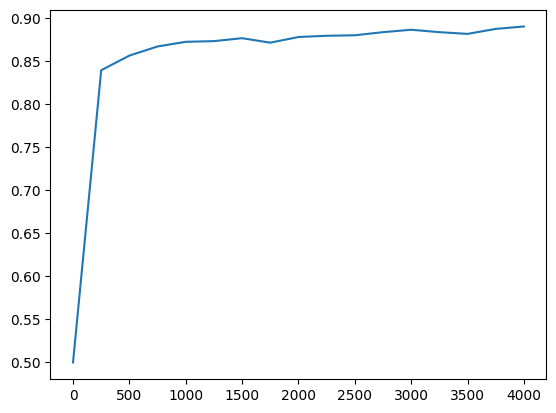

In [ ]:
plt.plot(np.arange(len(std_full_val_acc_history)) * val_interval, std_full_val_acc_history)

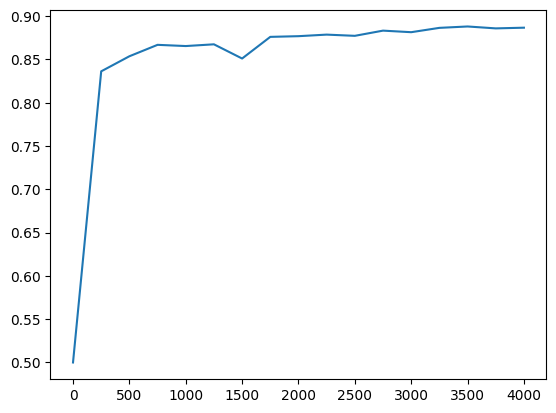

In [ ]:
plt.plot(np.arange(len(std_full_val_acc_history)) * val_interval, std_full_val_acc_history)

Al comienzo de este notebook descargamos el resultado de entrenar este modelo, usando la API de Hugging Face cargamos esos pesos y evaluamos como funciona este modelo en testing (puede tomar varios minutos)

In [ ]:
model = Model.from_pretrained(
    "./std_full_best2.pth/",
    return_dict=True,
    num_labels=2,
)
model.eval()
model = model.to(device)
validate(model, test_loader, device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/521 [00:00<?, ?it/s]

(tensor(0.4300, device='cuda:0'), tensor(0.8765, device='cuda:0'))

Podemos ver que cuando entrenamos con muchos datos parece que no hay dificultades, y el modelo alcanza un accuracy superior al 87%%.

## Entrenamiento estándar con pocos datos

Acá está el código para entrenar el mismo modelo (sin UDA) pero con la misma cantidad de datos supervisados que UDA. La idea es poder comparar los resultados entre los distintos modelos. Tampoco es necesario correrlo porque se demora aproximadamente 30 minutos.

In [ ]:
# En general no es necesario hacer esto, pero como el modelo
# es grande y el entrenamiento no esta encerrado dentro de una
# función podemos tener problemas de memoria
torch.cuda.empty_cache()

In [ ]:
model = Model.from_pretrained(
    model_name,
    return_dict=True,
    num_labels=2,
)
model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
lr = 2e-5
warmup = 0.1
total_steps = 1000

optim, scheduler = make_optimizer_and_scheduler(model, lr, warmup, total_steps)

model.train()

xe = nn.CrossEntropyLoss(reduction="none").to(device)

pbar = tqdm(range(total_steps))
model.train()
val_interval = 250
torch_one = torch.ones([], device=device, dtype=torch.float)
std_low_val_loss_history = []
std_low_val_acc_history = []
std_low_best_val_acc = 0.
for step in pbar:

    # sup part:
    inputs, labels = next(iter(train_loader20))

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    sup_loss, logits = calc_sup_loss(
        model, input_ids, attention_mask, labels, device,
    )
    sup_loss = sup_loss.mean()

    loss = sup_loss

    loss.backward()
    optim.step()
    scheduler.step()
    optim.zero_grad()

    pbar.set_postfix(
        sup_loss=sup_loss.item(),
    )

    if ((step % val_interval) == 0) or (step == (total_steps - 1)):
        print("Validation step", step)
        val_loss, val_acc = validate(model, val_loader, device=device)
        val_loss = val_loss.item()
        val_acc = val_acc.item()

        print(val_loss, val_acc)
        model.train()

        std_low_val_acc_history.append(val_acc)
        std_low_val_loss_history.append(val_loss)

        if val_acc > std_low_best_val_acc:
            std_low_best_val_acc = val_acc

            # model.save_pretrained("std_low_best.pth")

            print(f"\nNew best validation accuracy: {val_acc}\n")

  0%|          | 0/1000 [00:00<?, ?it/s]

Validation step 0


  0%|          | 0/105 [00:00<?, ?it/s]

1.0638717412948608 0.5708000063896179


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

3.2704927921295166 0.5893999934196472
Validation step 750


  0%|          | 0/105 [00:00<?, ?it/s]

3.4329464435577393 0.5881999731063843
Validation step 999


  0%|          | 0/105 [00:00<?, ?it/s]

3.4827189445495605 0.5888000130653381


Gráficamos como varió el accuracy de validacióon a lo largo del entrenamiento.

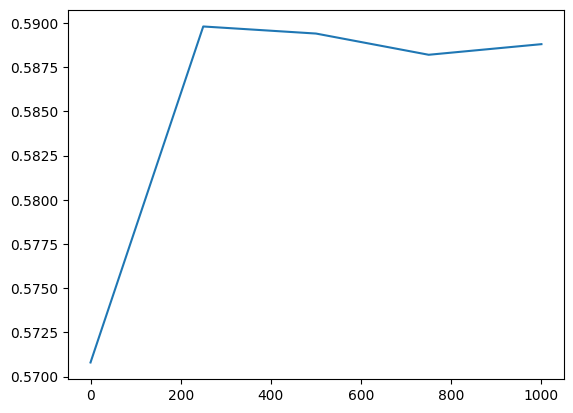

In [ ]:
plt.plot(np.arange(len(std_low_val_acc_history)) * val_interval, std_low_val_acc_history)

Finalmente vemos como se comporta el modelo con los datos de test (esto toma 3 minutos aproximadamente)

In [ ]:
%%time
model = Model.from_pretrained(
    "./std_low_best.pth/",
    return_dict=True,
    num_labels=2,
)
model = model.to(device)
model.eval()
print("Testing loss and accuracy:", validate(model, test_loader, device))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./std_low_best.pth/
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/521 [00:00<?, ?it/s]

Testing loss and accuracy: (tensor(2.1453, device='cuda:0'), tensor(0.6058, device='cuda:0'))
CPU times: user 1min 44s, sys: 1.23 s, total: 1min 45s
Wall time: 1min 14s


Ahora, si usamos solamente 20 datos etiquetados y a pesar de que usamos el modelo de BERT preentrenado, el modelo alcanza un accuracy cercano al 60%.

## UDA Training

Puede ser un poco más difícil de entrenar con UDA. Por ejemplo, dado que hay solamente 20 datos etiquetados el modelo se puede sobreentrenar muy rápido y después de esto dejar de aprender efectivamente.

Una forma de mitigar esto es que cuando el modelo predice la etiqueta de un ejemplo con mucha confianza se multiplica la pérdida asociada con ese ejemplo por 0, es decir, se le aplica una máscara. Durante el entrenamiento esto se va relajando: Al principio se aplica a los ejemplos con confianza mayor a 0.5, luego mayor a 0.6, y así sucesivamente hasta que no se le aplica a ningún ejemplo.

De esta forma, hacemos que el sobreentrenamiento sea también muy lento y el entrenamiento se concentre más en la pérdida de consistencia.

A continuación definimos la función para hacer esto:

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# TSA
def get_tsa_thresh(schedule, global_step, num_train_steps, start, end):
    training_progress = torch.tensor(float(global_step) / float(num_train_steps))
    if schedule == 'linear_schedule':
        threshold = training_progress
    elif schedule == 'exp_schedule':
        scale = 5
        threshold = torch.exp((training_progress - 1) * scale)
    elif schedule == 'log_schedule':
        scale = 5
        threshold = 1 - torch.exp((-training_progress) * scale)
    output = threshold * (end - start) + start
    return output.to(device)

Si graficamos los valores que toma está función:

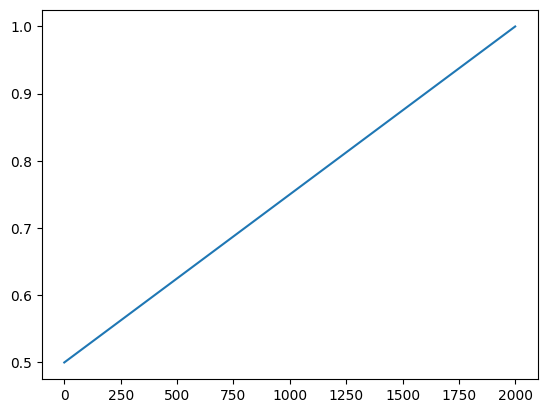

In [ ]:
import matplotlib.pyplot as plt
num_classes = 2
num_steps = 2000
plt.plot(np.arange(num_steps), np.asarray(list(map(lambda x: get_tsa_thresh("linear_schedule", x, num_steps, 1 / num_classes, end=1).cpu().numpy(), np.arange(num_steps)))))

Vemos que va linealmente desde 0.5 hasta 1, esto significa que en un principio la máxima confianza que puede tener el modelo para predecir la clase correcta es de 0.5 (aleatorio) y aumenta hasta llegar a 1.

Ahora vamos a ver como se entrena con UDA, en este caso ejecutar 10.000 pasos demora alrededor de 6 horas.

In [ ]:
model = Model.from_pretrained(model_name, return_dict=True)
model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
lr = 2e-5
tau = 1.0
tsa_schedule = "linear_schedule"

warmup = 0.1
total_steps = 5000
# total_steps = 2000

optim, scheduler = make_optimizer_and_scheduler(model, lr, warmup, total_steps)
model.train()

xe = nn.CrossEntropyLoss(reduction="none").to(device)
# Pytorch proveé una interfaz muy cómoda para calcular la KL-Divergencia
kl = nn.KLDivLoss(reduction="none").to(device)

pbar = tqdm(range(total_steps))
model.train()
val_interval = 250
torch_one = torch.ones([], device=device, dtype=torch.float)
uda_val_loss_history = []
uda_val_acc_history = []
uda_best_val_acc = 0.
running_sup_loss = 0.
running_unsup_loss = 0.
running_mask = 0.
for step in pbar:

    # sup data:
    inputs, labels = next(iter(train_loader20))
    labels = labels
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    # unsup data:
    src, bt = next(iter(unsup_loader))
    src_input_ids = src["input_ids"].to(device, non_blocking=True)
    src_attention_mask = src["attention_mask"].to(device, non_blocking=True)
    bt_input_ids = bt["input_ids"].to(device, non_blocking=True)
    bt_attention_mask = bt["attention_mask"].to(device, non_blocking=True)

    # parte supervisada
    sup_loss, logits = calc_sup_loss(
        model, input_ids, attention_mask, labels, device,
    )
    tsa_thresh = get_tsa_thresh(
        tsa_schedule, step, total_steps, 1 / logits.size(1), end=1
    ) # Calculamos cual es el valor de la confianza máxima en el paso actual
    larger_than_threshold = (-sup_loss).exp() > tsa_thresh # prob = exp(log_prob), prob > tsa_threshold
    # Creamos la máscara, toma valor 1 para los casos que no superan el threshold
    loss_mask = torch.ones_like(labels, device=device) * (1 - larger_than_threshold.float())
    # Multiplicamos la máscara para aplicarla
    sup_loss = (sup_loss * loss_mask.float()).sum() / torch.max(loss_mask.sum(), torch_one)

    # parte no supervisada

    # Como se mencionó antes, queremos que la predicción de la versión aumentada se acerque
    # a la predicción del dato sin aumentar. Para esto hacemos que no fluya el gradiente
    # al calcular las probabilidades de los datos sin aumentación
    with torch.no_grad():
        src_output = model(
            input_ids=src_input_ids, attention_mask=src_attention_mask, return_dict=True
        )
    # Y predecimos las probabilidades de los datos aumentados
    bt_output = model(
        input_ids=bt_input_ids, attention_mask=bt_attention_mask, return_dict=True
    )

    src_probs = src_output.logits.softmax(-1)
    # De acuerdo a la documentación de Pytorch (https://pytorch.org/docs/stable/generated/torch.nn.KLDivLoss.html)
    # la KL divergencia recibe como primer parámetro log-probabilidades (.log_softmax) y
    # como segundo parámetros probabilidades (.softmax)
    unsup_loss = kl((bt_output.logits / tau).log_softmax(-1), src_probs)
    unsup_loss = unsup_loss.mean()

    loss = sup_loss + unsup_loss

    loss.backward()
    optim.step()
    scheduler.step()
    optim.zero_grad()
    running_sup_loss += sup_loss
    running_unsup_loss += unsup_loss
    running_mask += loss_mask.sum()

    if (step % 5) == 0:
        pbar.set_postfix(
            sup_loss=running_sup_loss.item() / 5,
            unsup_loss=running_unsup_loss.item() / 5,
            loss_mask=running_mask.item() / 5,
        )
        running_sup_loss = 0.
        running_unsup_loss = 0.
        running_mask = 0.

    if (step > 0) and (((step % val_interval) == 0) or (step == (total_steps - 1))):
        print("Validation step", step)
        val_loss, val_acc = validate(model, val_loader, device=device)

        val_loss = val_loss.item()
        val_acc = val_acc.item()
        print(val_loss, val_acc)
        model.train()

        uda_val_acc_history.append(val_acc)
        uda_val_loss_history.append(val_loss)

        if val_acc > uda_best_val_acc:
            uda_best_val_acc = val_acc

            model.save_pretrained("uda_best3.pth")

            print(f"\nNew best validation accuracy: {val_acc}\n")

  0%|          | 0/5000 [00:00<?, ?it/s]

Validation step 250


  0%|          | 0/105 [00:00<?, ?it/s]

0.6983327269554138 0.524399995803833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/105 [00:00<?, ?it/s]

0.6078031063079834 0.6823999881744385


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


New best validation accuracy: 0.6823999881744385



KeyboardInterrupt: 

Y al graficar como se comporta el accuracy en validación durante entrenamiento vemos que le cuesta aprender, pero logra llegar a valores muy buenos.

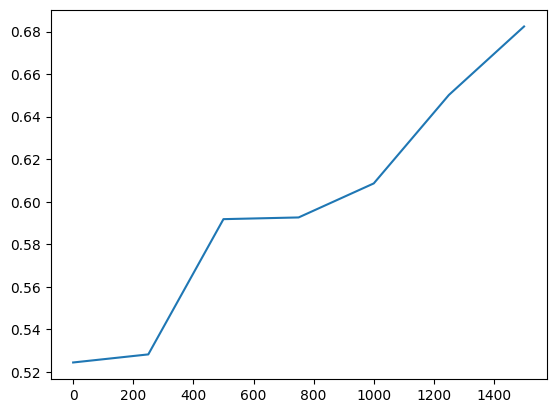

In [ ]:
plt.plot(np.arange(len(uda_val_acc_history)) * val_interval, uda_val_acc_history)

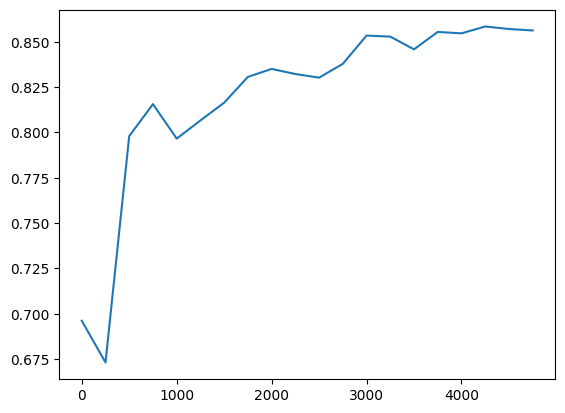

In [ ]:
plt.plot(np.arange(len(uda_val_acc_history)) * val_interval, uda_val_acc_history)

In [ ]:
%%time
model = Model.from_pretrained(
    "./uda_best4.pth/",
    return_dict=True,
    num_labels=2,
)
model = model.to(device)
model.eval()
print("Accuracy testing:", validate(model, test_loader, device))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/521 [00:00<?, ?it/s]

Accuracy testing: (tensor(0.3443, device='cuda:0'), tensor(0.8506, device='cuda:0'))
CPU times: user 1min 44s, sys: 1.16 s, total: 1min 45s
Wall time: 1min 14s


Finalmente, vemos que UDA tuvo acceso a las misma etiquetas, pero además lo entrenamos con la regularización para que tenga consistencia entre las predicciones de los datos y sus transformaciones, y alcanza un accuracy mayor al 80%, acortando sustancialmente la brecha con el modelo que uso 20.000 ejemplos.

# Actividades

Seleccionar 5 de las 6 actividades para contestar, cada una valdra 1.2 puntos.

## Actividad 1

Responda a la siguiente pregunta:

**¿Por qué cambian los ejemplos al aplicarle back-translation?**

In [ ]:
R = '' # @param{type: "string"}

## Actividad 2

A continuación se muestran algunos ejemplos de aumentación que se podría hacer a los datos. Para cada uno, indique si cree que funcionaría aplicar la *consistency loss* entre el dato original y el aumentado. Justifique su respuesta.

1. Cambiar algunas palabras por algún sinónimo

In [ ]:
R = '' # @param{type: "string"}

2. Cambiar algunas palabras por algún antónimo

In [ ]:
R = '' # @param{type: "string"}

3. Eliminar una palabra de cada ejemplo

In [ ]:
R = '' # @param{type: "string"}

4. Calcular la frecuencia de aparición de cada palabra en el dataset completo. Para cada ejemplo, reemplazar las palabras que se repiten **mucho** en el dataset por un token aleatorio. **Ayuda:** La frecuencia de una palabra generalmente se relaciona con qué tanta información entrega esa palabra.

In [ ]:
R = '' # @param{type: "string"}

5. Hacer lo mismo que en el punto anterior, pero reemplazar las palabras que se repiten **poco**.

In [ ]:
R = '' # @param{type: "string"}

## Actividad 3

Elija una de las siguientes preguntas y respóndala.

1. Plantee otra aumentación que se podría hacer a los datos (que no esté en la Actividad 2).

2. Plantee una forma de filtrar lo más posible los ejemplos ruidosos del back-translation.

3. Elija un dominio de datos distinto a texto e imágenes y comente cómo podría aplicar UDA.

Indique el número de la pregunta que eligió y responda.

In [ ]:
R = '' # @param{type: "string"}

## Actividad 4

Aplique back-translation como mínimo a 3 ejemplos propuestos por usted y con 3 temperaturas de muestreo distintas para cada uno. Luego responda a las preguntas. (Mas información util sobre temperatura y sampling [aqui](https://huggingface.co/blog/how-to-generate))

In [ ]:
import torch
from transformers import MarianMTModel, MarianTokenizer

torch.cuda.empty_cache()

en_fr_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
en_fr_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-fr").cuda()

fr_en_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-fr-en")
fr_en_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-fr-en").cuda()

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
src_text = [
    "Hi how are you?",
    "Hi how are you?",
    "Hi how are you?",
    "I think that movie is really cool",
    "I think that movie is really cool",
    "I think that movie is really cool",
    "I really like this movie",
    "I really like this movie",
    "I really like this movie",
    "How many times have you had to search how to make an array in Java?",
    "How many times have you had to search how to make an array in Java?",
    "How many times have you had to search how to make an array in Java?",
]

In [ ]:
translated_tokens = en_fr_model.generate(
    **{k: v.cuda() for k, v in en_fr_tokenizer(src_text, return_tensors="pt", padding=True).items()},
    do_sample=True,
    top_k=10,
    temperature=2.5,
)
in_fr = [en_fr_tokenizer.decode(t, skip_special_tokens=True) for t in translated_tokens]
in_fr

['Comment allez-vous ?',
 'Comment allez-vous ?',
 'Comment allez-vous ?',
 "Je pense que ce film c'est vraiment cool.",
 'Je pense que ce film est vraiment sympa.',
 'Je pense que ce film est vraiment sympa.',
 'Ce film me plaît vraiment.',
 "J'aime vraiment ce film.",
 "J'aime vraiment ce film.",
 'Combien de fois avez-vous dû rechercher comment créer un tableau en Java ?',
 'Combien de fois avez-vous dû chercher comment créer un tableau en Java ?',
 'Combien de fois avez-vous dû rechercher comment créer un tableau en Java ?']

In [ ]:
bt_tokens = fr_en_model.generate(
    **{k: v.cuda() for k, v in fr_en_tokenizer(in_fr, return_tensors="pt", padding=True).items()},
    do_sample=True,
    top_k=10,
    temperature=2.0,
)
in_en = [fr_en_tokenizer.decode(t, skip_special_tokens=True) for t in bt_tokens]
in_en

['How are you?',
 'How are you?',
 'How do you do?',
 'I think this movie is really cool.',
 'I think this movie is really nice.',
 "I think this movie's really nice.",
 "I'm really enjoying this movie.",
 'I really like this movie.',
 'I really like this movie.',
 'How many times did you have to search for how to create an array in Java?',
 'How many times have you had to look how to create an array in Java?',
 'How many times did you have to search how to create an array in Java?']

**Copie y pegue los ejemplos a los que aplicó back-translation y sus aumentaciones**

In [ ]:
Ejemplo_1 = 'Hola como estas' # @param {type: "string"}
Aumentacion_1 = 'resultado tempertura 0.1: ' # @param {type: "string"}
Aumentacion_2 = 'resultado tempertura 1.5' # @param {type: "string"}
Aumentacion_3 = 'resultado tempertura 3.5' # @param {type: "string"}

In [ ]:
Ejemplo_2 = '' # @param {type: "string"}
Aumentacion_1 = '' # @param {type: "string"}
Aumentacion_2 = '' # @param {type: "string"}
Aumentacion_3 = '' # @param {type: "string"}

In [ ]:
Ejemplo_3 = '' # @param {type: "string"}
Aumentacion_1 = '' # @param {type: "string"}
Aumentacion_2 = '' # @param {type: "string"}
Aumentacion_3 = '' # @param {type: "string"}

**¿En qué influye cambiar la temperatura de muestreo?**

In [ ]:
R = '' # @param {type: "string"}

## Actividad 5

Entrene el modelo con UDA, pero ahora en vez de utilizar solamente 20 etiquetas de entrenamiento utilice todas las disponibles (las 20.000), ejecute el entrenamiento por almenos 500 pasos (debería tomar unos 30 minutos), es libre de entrenar por más tiempo. Finalmente grafique el accuracy en validación a lo largo del tiempo y calcule el accuracy en el set de test.

In [ ]:
## Ingrese su código aquí

## Actividad 6

De al menos una ventajas y una desventajas pueden haber entre usar un preentrenamiento como contrastive learning frente a usar UDA.

In [ ]:
R = '' # @param {type: "string"}